# Activité 3 : Clustering, Analyse PCA et Profilage des Segments

# Chargement des données

In [1]:
# Limitation des threads pour éviter l'avertissement de fuite de mémoire de K-means sous Windows
# (doit être placé avant tous les autres imports)
import os
os.environ["OMP_NUM_THREADS"] = "1"

# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset RFM (valeurs réelles, pour interpréter les clusters)
rfm = pd.read_csv("rfm.csv", index_col="CustomerID")

# Chargement du dataset prétraité (pour le clustering)
X_scaled = pd.read_csv("rfm_scaled.csv", index_col="CustomerID")

# Vérification des dimensions
print(rfm.shape, X_scaled.shape)

(4338, 3) (4338, 3)


# Application de K-means Clustering sur Online Retail

# Étape 1 : Sélection du nombre optimal de clusters (K)

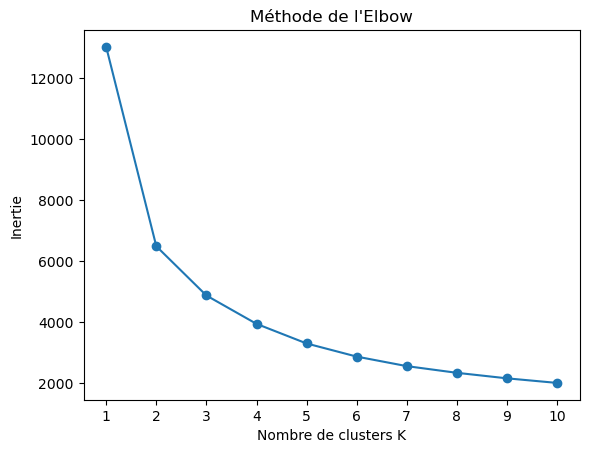

In [2]:
# Import de la classe KMeans
from sklearn.cluster import KMeans

# Liste qui va stocker l'inertie obtenue pour chaque valeur de K
inerties = []

# Boucle : on teste K de 1 à 10
for k in range(1, 11):
    # Création du modèle K-means avec k clusters
    kmeans = KMeans(n_clusters=k, random_state=0)
    # Ajustement du modèle sur les données standardisées
    kmeans.fit(X_scaled)
    # Récupération de l'inertie et ajout à la liste
    inerties.append(kmeans.inertia_)

# Tracé de la courbe de l'Elbow : inertie en fonction de K
plt.plot(range(1, 11), inerties, marker="o")
plt.xticks(range(1, 11))
plt.xlabel("Nombre de clusters K")
plt.ylabel("Inertie")
plt.title("Méthode de l'Elbow")
plt.show()

Le coude le plus marqué se situe à K = 2 : l'inertie est divisée par deux entre 1 et 2 clusters. Cependant, 2 clusters seraient trop peu nombreux pour une segmentation marketing utile.

La courbe continue de s'infléchir jusqu'à K = 4 : au-delà, chaque cluster supplémentaire ne réduit plus que faiblement l'inertie. Un choix raisonnable est donc K = 4. 

In [29]:
# Indicateurs de qualité des clusters pour plusieurs valeurs de K
from sklearn.metrics import silhouette_score

resultats = []

for k in range(2, 9):
    # Modèle K-means avec k clusters (mêmes paramètres que le modèle retenu)
    km = KMeans(n_clusters=k, random_state=0)
    labels = km.fit_predict(X_scaled)

    # Inertie, silhouette pour ce K
    resultats.append({
        "K": k,
        "Inertie": round(km.inertia_),
        "Silhouette": round(silhouette_score(X_scaled, labels), 3),
    })

# Tableau récapitulatif
tableau_k = pd.DataFrame(resultats)

# Baisse d'inertie en % par rapport au K précédent
tableau_k["Baisse inertie (%)"] = (-tableau_k["Inertie"].pct_change() * 100).round(1)

tableau_k

,K,Inertie,Silhouette,Baisse inertie (%)
0,2,6484,0.433,NaN
1,3,4870,0.339,24.9
2,4,3941,0.333,19.1
3,5,3298,0.316,16.3
4,6,2868,0.306,13.0
5,7,2556,0.302,10.9
6,8,2337,0.304,8.6


<table style="margin-left: auto; margin-right: auto;">
  <tr>
    <th style="text-align: center;">K</th>
    <th style="text-align: center;">Inertie</th>
    <th style="text-align: center;">Baisse d'inertie</th>
    <th style="text-align: center;">Silhouette<br>(plus élevé = mieux)</th>
    <th style="text-align: center;">Lecture</th>
  </tr>
  <tr>
    <td style="text-align: center;">1</td>
    <td style="text-align: center;">13 014</td>
    <td style="text-align: center;">–</td>
    <td style="text-align: center;">non calculable</td>
    <td style="text-align: center;">Point de départ : tous les clients dans un seul groupe</td>
  </tr>
  <tr>
    <td style="text-align: center;">2</td>
    <td style="text-align: center;">6 484</td>
    <td style="text-align: center;">−50,2 %</td>
    <td style="text-align: center;">0,433</td>
    <td style="text-align: center;">Meilleure silhouette, mais 2 groupes trop grossiers pour le marketing</td>
  </tr>
  <tr>
    <td style="text-align: center;">3</td>
    <td style="text-align: center;">4 870</td>
    <td style="text-align: center;">−24,9 %</td>
    <td style="text-align: center;">0,339</td>
    <td style="text-align: center;">Gain encore important</td>
  </tr>
  <tr style="background-color: #EEF2F7;">
    <td style="text-align: center;"><b>4</b></td>
    <td style="text-align: center;"><b>3 941</b></td>
    <td style="text-align: center;"><b>−19,1 %</b></td>
    <td style="text-align: center;"><b>0,333</b></td>
    <td style="text-align: center;"><b>Choix retenu : dernier gain net, silhouette stable</b></td>
  </tr>
  <tr>
    <td style="text-align: center;">5</td>
    <td style="text-align: center;">3 298</td>
    <td style="text-align: center;">−16,3 %</td>
    <td style="text-align: center;">0,316</td>
    <td style="text-align: center;">Gain plus faible, silhouette en baisse</td>
  </tr>
  <tr>
    <td style="text-align: center;">6</td>
    <td style="text-align: center;">2 868</td>
    <td style="text-align: center;">−13,0 %</td>
    <td style="text-align: center;">0,306</td>
    <td style="text-align: center;">Gain faible, silhouette en baisse</td>
  </tr>
</table>

Les indicateurs statistiques départagent peu K = 4 et K = 5 : la baisse d'inertie ralentit progressivement, sans rupture nette entre les deux. Le coefficient de silhouette est toutefois légèrement plus élevé pour K = 4 (0,333 contre 0,316) : les clusters y sont un peu plus compacts et mieux séparés.

Ce léger avantage statistique rejoint l'argument métier : avec 4 clusters, chaque segment correspond à un persona clair et directement actionnable (Champions, Occasionnels, Nouveaux clients, Inactifs). Un cinquième cluster compliquerait le pilotage marketing sans gain significatif de qualité. Nous retenons donc K = 4.

# Étape 2 : Appliquer K-means avec le nombre optimal de clusters

In [4]:
# Nombre de clusters choisi grâce à la méthode de l'Elbow
K = 4

# Création du modèle K-means avec K clusters
kmeans = KMeans(n_clusters=K, random_state=0)

# Ajustement du modèle sur les données standardisées
kmeans.fit(X_scaled)

# Ajout du numéro de cluster de chaque client dans le dataset RFM
rfm["Cluster"] = kmeans.labels_

# Vérification : premières lignes du dataset
rfm.head()

,Recence,Frequence,Montant,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,1
12348.0,75,4,1797.24,3
12349.0,19,1,1757.55,2
12350.0,310,1,334.40,0


In [5]:
# Nombre de clients dans chaque cluster
rfm["Cluster"].value_counts()

Cluster
0    1583
3    1182
2     872
1     701
Name: count, dtype: int64

In [6]:
# Moyenne de chaque métrique par cluster
rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].mean().round(1)

,Recence,Frequence,Montant
Cluster,,,
0,188.9,1.4,361.7
1,11.5,13.8,8142.7
2,21.2,2.0,494.6
3,64.3,4.2,1840.4


Les clusters sont déséquilibrés : leurs effectifs vont de 701 à 1 583 clients.

Les regroupements semblent cohérents et chaque cluster présente un profil bien distinct :

- Cluster 1 (701 clients) : achat très récent (12 jours en moyenne), très fréquent (14 commandes) et montant très élevé (8 143). Ce sont les meilleurs clients.
- Cluster 3 (1 182 clients) : achat assez récent (64 jours), fréquence moyenne (4 commandes) et montant intermédiaire (1 840). Ce sont des clients occassionels.
- Cluster 2 (872 clients) : achat très récent (21 jours), mais seulement 2 commandes et un montant faible (495). Ce sont probablement de nouveaux clients.
- Cluster 0 (1 583 clients) : dernier achat ancien (189 jours, soit plus de 6 mois), une seule commande en moyenne et un montant faible (362). Ce sont des clients inactifs ou perdus.

On retrouve les liens observés dans l'analyse des corrélations : les clients qui achètent souvent sont aussi ceux qui dépensent le plus, et ils ont généralement acheté récemment. À l'inverse, les clients inactifs depuis longtemps ont peu commandé et peu dépensé.

# Étape 3 : Visualisation des clusters

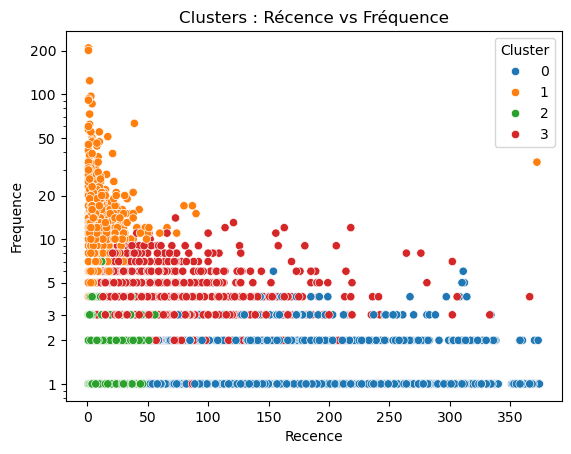

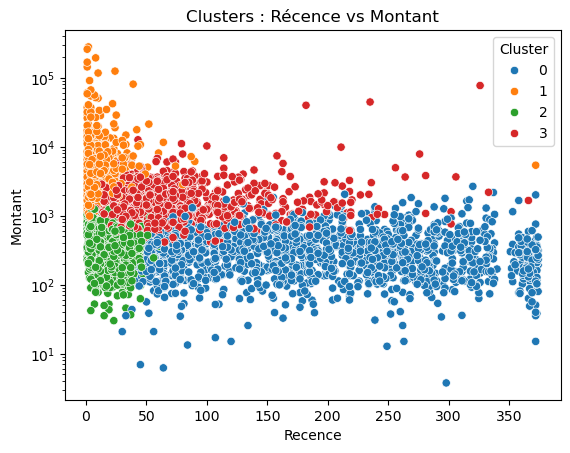

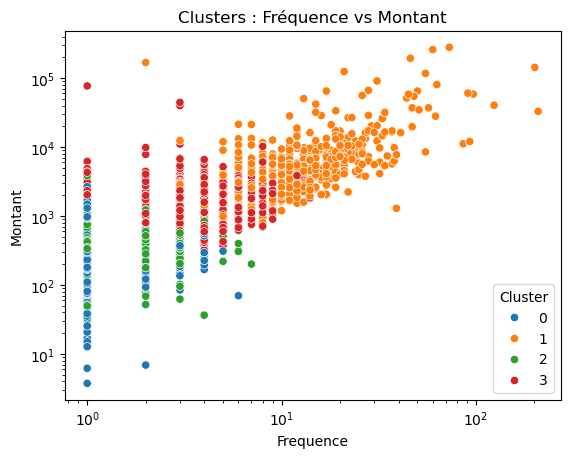

In [7]:
# Récence vs Fréquence, coloré par cluster
sns.scatterplot(x=rfm["Recence"], y=rfm["Frequence"], hue=rfm["Cluster"], palette="tab10")
# Échelle logarithmique sur l'axe vertical pour rendre le graphique lisible
plt.yscale("log")
# Graduations lisibles sur l'axe de la fréquence
plt.yticks([1, 2, 3, 5, 10, 20, 50, 100, 200], [1, 2, 3, 5, 10, 20, 50, 100, 200])
plt.title("Clusters : Récence vs Fréquence")
plt.show()

# Récence vs Montant
sns.scatterplot(x=rfm["Recence"], y=rfm["Montant"], hue=rfm["Cluster"], palette="tab10")
# Échelle logarithmique sur l'axe vertical
plt.yscale("log")
plt.title("Clusters : Récence vs Montant")
plt.show()

# Fréquence vs Montant
sns.scatterplot(x=rfm["Frequence"], y=rfm["Montant"], hue=rfm["Cluster"], palette="tab10")
# Échelle logarithmique sur les deux axes
plt.xscale("log")
plt.yscale("log")
plt.title("Clusters : Fréquence vs Montant")
plt.show()

- Récence vs Fréquence : le cluster 1 se situe en haut à gauche : des clients qui ont acheté récemment et très souvent (souvent plus de 5 commandes). Le cluster 2 est en bas à gauche : des achats récents (moins de 50 jours), mais seulement 1 à 3 commandes. Le cluster 0 s'étale en bas à droite : des clients qui n'ont pas acheté depuis longtemps et qui n'ont passé qu'une ou deux commandes. Le cluster 3 occupe une position intermédiaire, avec 3 à 10 commandes et une récence très variable. Les points sont alignés en lignes horizontales parce que la fréquence est un nombre entier de commandes.

- Récence vs Montant : c'est le graphique où les clusters sont les plus nettement séparés. Le cluster 1 regroupe les montants les plus élevés et les achats les plus récents. Le cluster 3 forme une bande intermédiaire (environ 1 000 à 10 000). Les clusters 2 et 0 ont tous deux des montants faibles, mais une frontière nette autour de 50 jours de récence les sépare : le cluster 2 regroupe les clients récents et le cluster 0 les clients inactifs.

- Fréquence vs Montant : on observe une relation positive : plus un client commande, plus il dépense. Le cluster 1 se détache en haut à droite. À gauche (1 à 4 commandes), les clusters 0, 2 et 3 se superposent : ils se distinguent surtout par la récence, qui n'apparaît pas sur ce graphique.

Des segments spécifiques apparaissent clairement. Les clients récents et très dépensiers correspondent au cluster 1, et les clients inactifs à faible montant au cluster 0. Le cluster 2 représente des clients récents mais encore peu engagés, probablement de nouveaux clients. Le cluster 3 correspond à des clients réguliers de valeur intermédiaire.

# Étape 4 : Interprétation des clusters

In [8]:
# Moyenne de chaque métrique par cluster
rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].mean().round(1)

,Recence,Frequence,Montant
Cluster,,,
0,188.9,1.4,361.7
1,11.5,13.8,8142.7
2,21.2,2.0,494.6
3,64.3,4.2,1840.4


In [9]:
# Médiane de chaque métrique par cluster
rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].median().round(1)

,Recence,Frequence,Montant
Cluster,,,
0,184.0,1.0,304.2
1,8.0,10.0,3719.1
2,19.0,2.0,418.5
3,51.0,4.0,1374.3


Pour décrire les clusters, on retient la médiane plutôt que la moyenne. Les distributions RFM sont très asymétriques : quelques clients aux valeurs extrêmes peuvent tirer la moyenne vers le haut. C'est surtout le cas pour le cluster 1, dont le montant moyen (8 143) est plus de deux fois supérieur au montant médian (3 719), à cause de quelques clients qui dépensent plus de 100 000. Pour les autres clusters, moyennes et médianes sont proches. La médiane donne donc une image plus fidèle du client type de chaque segment.

Profils des clusters (valeurs médianes) :

- Cluster 1 : les meilleurs clients (701 clients). Dernier achat il y a 8 jours, 10 commandes, montant de 3 719. Ils achètent récemment, souvent et beaucoup : ce sont les clients les plus précieux.
- Cluster 3 : les clients occasionnels (1 182 clients). Dernier achat il y a 51 jours, 4 commandes, montant de 1 374. Ce sont de bons clients, mais moins engagés que ceux du cluster 1.
- Cluster 2 : les nouveaux clients (872 clients). Dernier achat il y a 19 jours, mais seulement 2 commandes et un montant de 419. Ils viennent probablement d'arriver.
- Cluster 0 : les clients inactifs (1 583 clients). Dernier achat il y a 184 jours (plus de 6 mois), une seule commande et un montant de 304. Ce sont probablement des clients perdus.

Apport de la visualisation :

Les graphiques confirment ces profils, en particulier le graphique Récence vs Montant, où les quatre clusters sont bien séparés. Ils précisent aussi la différence entre les clusters 2 et 0 : tous deux ont peu commandé et peu dépensé, mais ils sont séparés par la récence, autour de 50 jours. On distingue donc les nouveaux clients, qui viennent d'acheter, des clients inactifs, qui ne reviennent plus.

Actions marketing :

- Cluster 1 : fidélisation et produits premium (programme VIP, avantages exclusifs, accès en avant-première aux nouveautés), pour garder ces clients.
- Cluster 3 : offres personnalisées et programme de points, pour les encourager à commander plus souvent et les faire passer dans le cluster 1.
- Cluster 2 : accueil et incitation à un deuxième achat (réduction sur la prochaine commande, e-mail de bienvenue), pour les transformer en clients réguliers.
- Cluster 0 : campagnes de relance (offre promotionnelle forte, e-mail du type « vous nous manquez »), pour tenter de les faire revenir. Comme ils rapportent peu, ces actions doivent rester peu coûteuses.

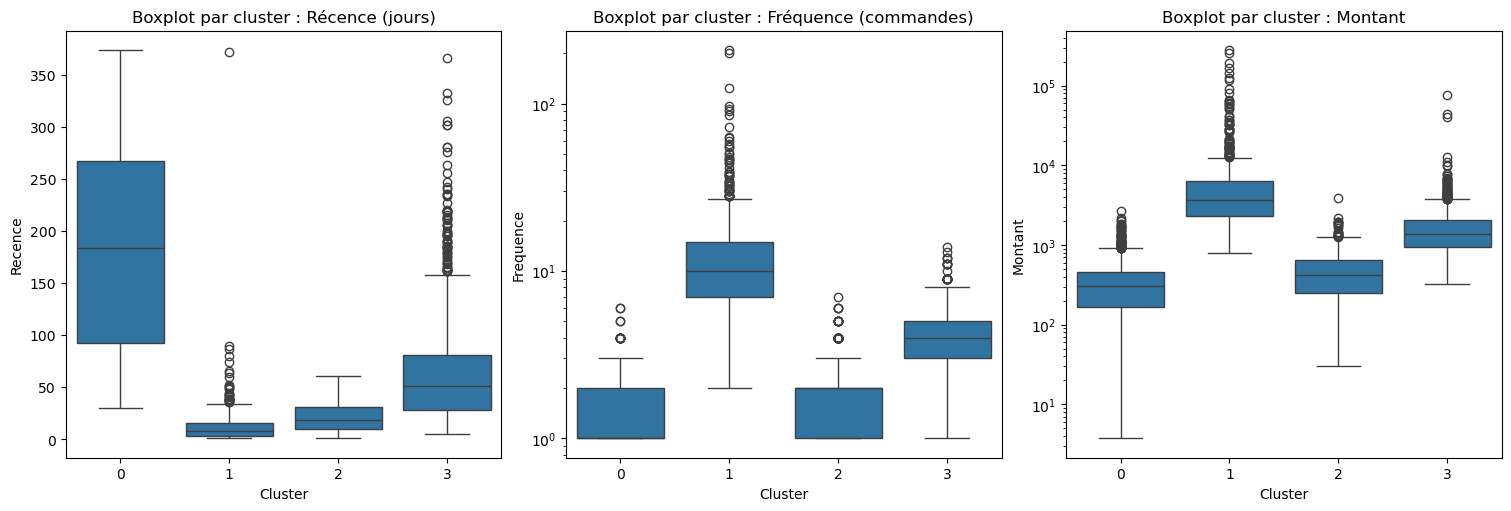

In [10]:
# Boxplots des 3 métriques RFM par segment (grille 1 x 3)
colonnes = ["Recence", "Frequence", "Montant"]
titres = ["Récence (jours)", "Fréquence (commandes)", "Montant"]

# Création de la figure avec 3 graphiques côte à côte
fig, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

# Un boxplot par métrique, avec un boxplot par cluster
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.boxplot(x=rfm["Cluster"], y=rfm[col], ax=ax)
    ax.set_title(f"Boxplot par cluster : {titre}")

# Échelle logarithmique pour la fréquence et le montant, pour rendre les boxplots lisibles
axs[1].set_yscale("log")
axs[2].set_yscale("log")

# Affichage
plt.show()

# Application du Clustering hiérarchique au Retail online

# Étape 1 : Calcul des distances et construction du dendrogramme

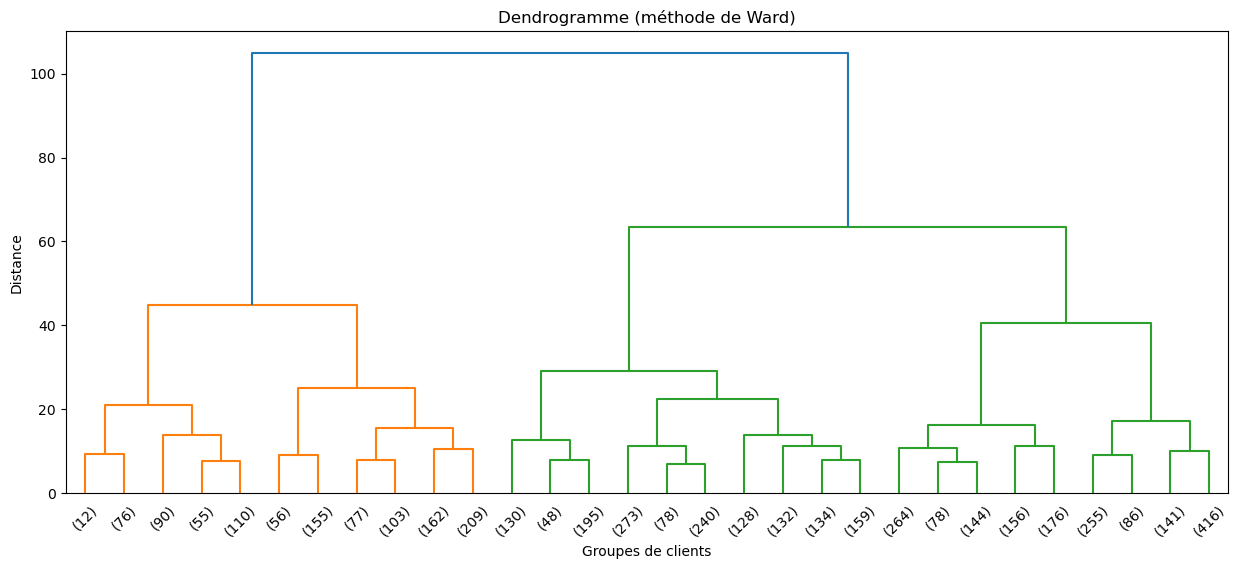

In [11]:
# Import des fonctions de clustering hiérarchique
from scipy.cluster.hierarchy import dendrogram, linkage

# Calcul des distances et regroupement progressif des clients (méthode de Ward)
Z = linkage(X_scaled, method="ward")

# Tracé du dendrogramme, limité aux 30 derniers regroupements pour rester lisible
plt.figure(figsize=(15, 6))
dendrogram(Z, truncate_mode="lastp", p=30)
plt.title("Dendrogramme (méthode de Ward)")
plt.xlabel("Groupes de clients")
plt.ylabel("Distance")
plt.show()

Une coupe vers une distance de 35, dans une zone sans fusion entre 30 et 40, donne 5 clusters. 

# Étape 2 : Appliquer le clustering hiérarchique avec un nombre de clusters spécifique

In [12]:
# Import de la classe de clustering hiérarchique
from sklearn.cluster import AgglomerativeClustering

# Nombre de clusters choisi grâce au dendrogramme
n_clusters = 5

# Création du modèle avec le même critère de liaison que le dendrogramme
hc = AgglomerativeClustering(n_clusters=n_clusters, linkage="ward")

# Entraînement du modèle et récupération des labels en une seule étape
rfm["Cluster_HC"] = hc.fit_predict(X_scaled)

# Vérification : premières lignes du dataset
rfm.head()

,Recence,Frequence,Montant,Cluster,Cluster_HC
CustomerID,,,,,
12346.0,326,1,77183.60,3,0
12347.0,2,7,4310.00,1,1
12348.0,75,4,1797.24,3,0
12349.0,19,1,1757.55,2,0
12350.0,310,1,334.40,0,2


In [13]:
# Nombre de clients dans chaque cluster hiérarchique
rfm["Cluster_HC"].value_counts()

Cluster_HC
0    1517
2     898
4     818
1     762
3     343
Name: count, dtype: int64

Le clustering hiérarchique forme 5 clusters, contre 4 pour K-means. Leurs effectifs vont de 343 à 1 517 clients, contre 701 à 1 583 clients avec K-means.

Les clusters hiérarchiques sont donc un peu moins équilibrés : le plus gros a une taille comparable à celui de K-means (environ 1 500 clients), mais le plus petit est deux fois plus réduit (343 clients). Ce petit cluster pourrait correspondre à un segment très spécifique, par exemple les meilleurs clients. La comparaison des profils permettra de le vérifier.

# Étape 3 : Visualisation des clusters hiérarchiques

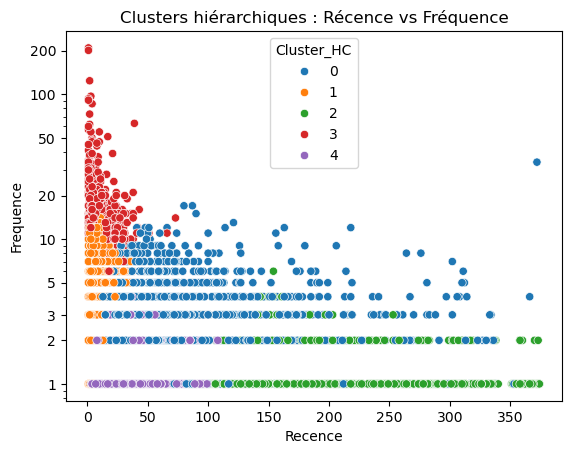

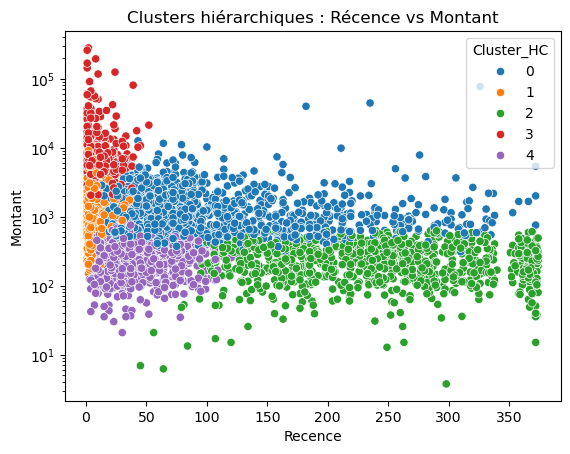

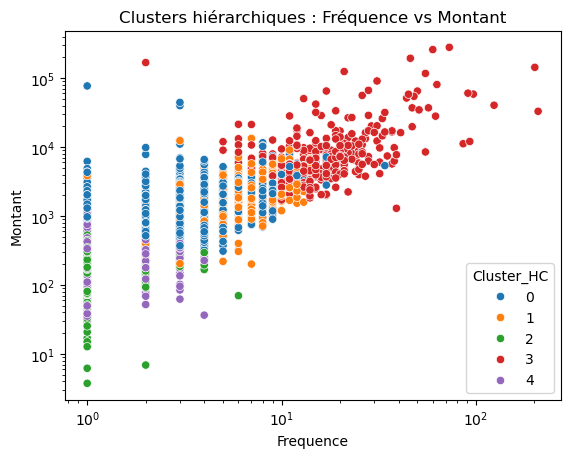

In [14]:
# Récence vs Fréquence, coloré par cluster hiérarchique
sns.scatterplot(x=rfm["Recence"], y=rfm["Frequence"], hue=rfm["Cluster_HC"], palette="tab10")
# Échelle logarithmique sur l'axe vertical pour rendre le graphique lisible
plt.yscale("log")
# Graduations lisibles sur l'axe de la fréquence
plt.yticks([1, 2, 3, 5, 10, 20, 50, 100, 200], [1, 2, 3, 5, 10, 20, 50, 100, 200])
plt.title("Clusters hiérarchiques : Récence vs Fréquence")
plt.show()

# Récence vs Montant
sns.scatterplot(x=rfm["Recence"], y=rfm["Montant"], hue=rfm["Cluster_HC"], palette="tab10")
# Échelle logarithmique sur l'axe vertical
plt.yscale("log")
plt.title("Clusters hiérarchiques : Récence vs Montant")
plt.show()

# Fréquence vs Montant
sns.scatterplot(x=rfm["Frequence"], y=rfm["Montant"], hue=rfm["Cluster_HC"], palette="tab10")
# Échelle logarithmique sur les deux axes
plt.xscale("log")
plt.yscale("log")
plt.title("Clusters hiérarchiques : Fréquence vs Montant")
plt.show()

# Étape 4 : Interprétation des Clusters Hiérarchiques

Regroupements spécifiques du clustering hiérarchique :

- Cluster 3 (rouge, 343 clients) : clients très récents, très fréquents (souvent plus de 10 commandes) et aux montants les plus élevés. Il isole les tout meilleurs clients, l'élite de la clientèle.
- Cluster 1 (orange, 762 clients) : clients récents (moins de 50 jours environ), avec une fréquence et un montant moyens à élevés. Ce sont de bons clients actifs, mais légèrement en dessous du cluster 3.
- Cluster 0 (bleu, 1 517 clients) : clients à la récence très variable, avec quelques commandes et des montants intermédiaires. Ce sont des clients occasionnels, mais moins actifs récemment.
- Cluster 4 (violet, 818 clients) : clients assez récents (moins de 100 jours), mais avec peu de commandes et des montants faibles. Ce sont probablement de nouveaux clients.
- Cluster 2 (vert, 898 clients) : clients qui n'ont pas acheté depuis longtemps (plus de 100 jours), avec 1 ou 2 commandes et des montants faibles. Ce sont des clients inactifs.

Comparaison avec K-means :

Les deux approches montrent des patterns similaires : dans les deux cas, le graphique Récence vs Montant sépare bien les clusters, et on retrouve les mêmes grands types de clients (meilleurs clients, réguliers, nouveaux, inactifs).

Elles sont aussi complémentaires. La principale différence concerne les meilleurs clients : K-means les regroupait dans un seul cluster de 701 clients, alors que le clustering hiérarchique les sépare en deux, avec d'un côté une élite très rentable (cluster 3) et de l'autre de bons clients récents (cluster 1). Le clustering hiérarchique permet donc d'identifier plus finement les clients à plus forte valeur, ce qui est utile pour cibler des actions premium.

La frontière entre nouveaux clients et clients inactifs se situe aussi plus loin : vers 100 jours de récence, contre environ 50 jours avec K-means.

In [15]:
# Moyenne de chaque métrique par cluster hiérarchique
rfm.groupby("Cluster_HC")[["Recence", "Frequence", "Montant"]].mean().round(1)

,Recence,Frequence,Montant
Cluster_HC,,,
0,91.0,3.5,1558.7
1,9.7,5.5,1811.1
2,241.0,1.2,249.7
3,13.0,20.3,13640.8
4,43.0,1.3,293.0


In [16]:
# Médiane de chaque métrique par cluster hiérarchique
rfm.groupby("Cluster_HC")[["Recence", "Frequence", "Montant"]].median().round(1)

,Recence,Frequence,Montant
Cluster_HC,,,
0,67.0,3.0,1021.5
1,8.0,5.0,1451.9
2,243.0,1.0,226.4
3,9.0,15.0,6127.4
4,39.0,1.0,280.0


Comme pour K-means, les profils sont décrits avec la médiane, plus fidèle au client type. L'écart est particulièrement marqué pour le cluster 3 : son montant moyen (13 641) est plus de deux fois supérieur à son montant médian (6 127), à cause de quelques clients aux dépenses exceptionnelles.

Profils des clusters hiérarchiques (valeurs médianes)

- Cluster 3 : l'élite (343 clients). Dernier achat il y a 9 jours, 15 commandes, montant de 6 127. Ce sont les clients les plus fidèles et les plus rentables.
- Cluster 1 : les bons clients actifs (762 clients). Dernier achat il y a 8 jours, 5 commandes, montant de 1 452. Très récents, avec une bonne fréquence, mais un montant bien inférieur à celui de l'élite.
- Cluster 0 : les clients occasionnels (1 517 clients). Dernier achat il y a 67 jours, 3 commandes, montant de 1 022. De bons clients, mais dont l'activité ralentit.
- Cluster 4 : les nouveaux clients (818 clients). Dernier achat il y a 39 jours, 1 seule commande, montant de 280.
- Cluster 2 : les clients perdus (898 clients). Dernier achat il y a 243 jours (environ 8 mois), 1 seule commande, montant de 226.

Comparaison avec K-means

Certains segments se ressemblent : les nouveaux clients (cluster 4 hiérarchique et cluster 2 K-means) ont des profils et des effectifs proches. Les clients occasionnels se retrouvent aussi dans les deux méthodes (cluster 0 hiérarchique et cluster 3 K-means).

Le clustering hiérarchique apporte deux nouveaux éclairages :

Il distingue deux niveaux parmi les meilleurs clients. K-means les regroupait dans un seul cluster de 701 clients (médiane : 10 commandes, 3 719). Le clustering hiérarchique isole une élite de 343 clients (15 commandes, 6 127), beaucoup plus rentable que les autres bons clients (5 commandes, 1 452). C'est utile pour réserver les actions les plus coûteuses (offres VIP, services premium) aux clients qui rapportent le plus.
Il définit les clients inactifs de façon plus stricte. Son cluster d'inactifs est plus petit (898 clients contre 1 583) et plus ancien (243 jours contre 184). Il ne retient que les clients vraiment perdus, et rattache les autres aux clients réguliers moins récents.

## Comparaison des résultats entre K-means et clustering hiérarchique

In [17]:
# 1. Comparer les tailles des clusters
print("Tailles des clusters K-means :")
print(rfm["Cluster"].value_counts())

print("Tailles des clusters hiérarchiques :")
print(rfm["Cluster_HC"].value_counts())

Tailles des clusters K-means :
Cluster
0    1583
3    1182
2     872
1     701
Name: count, dtype: int64
Tailles des clusters hiérarchiques :
Cluster_HC
0    1517
2     898
4     818
1     762
3     343
Name: count, dtype: int64


In [18]:
# 2. Comparer les caractéristiques médianes
variables = ["Recence", "Frequence", "Montant"]

print("Médianes par cluster K-means :")
display(rfm.groupby("Cluster")[variables].median().round(1))

print("Médianes par cluster hiérarchique :")
display(rfm.groupby("Cluster_HC")[variables].median().round(1))

Médianes par cluster K-means :


,Recence,Frequence,Montant
Cluster,,,
0,184.0,1.0,304.2
1,8.0,10.0,3719.1
2,19.0,2.0,418.5
3,51.0,4.0,1374.3


Médianes par cluster hiérarchique :


,Recence,Frequence,Montant
Cluster_HC,,,
0,67.0,3.0,1021.5
1,8.0,5.0,1451.9
2,243.0,1.0,226.4
3,9.0,15.0,6127.4
4,39.0,1.0,280.0


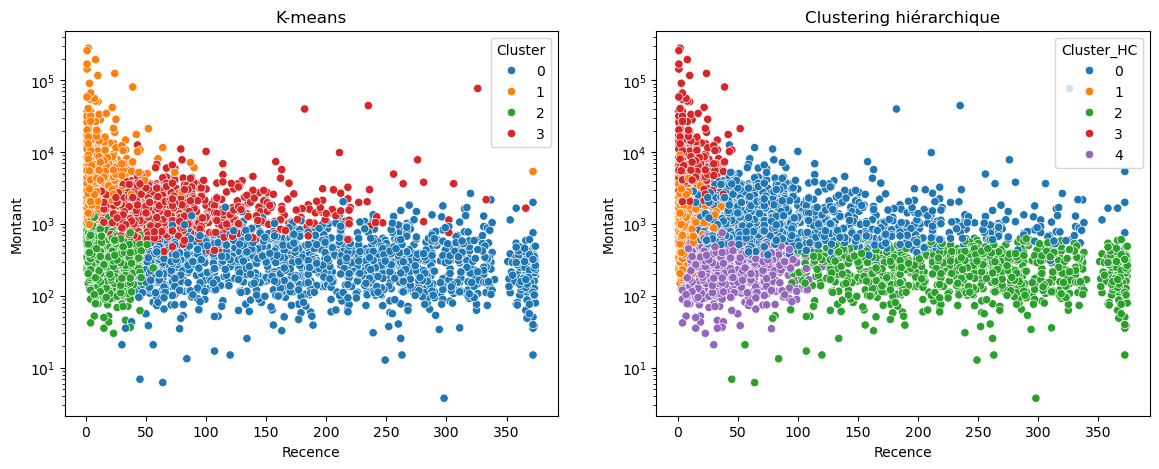

In [19]:
# 3. Visualiser les clusters côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique de gauche : K-means
sns.scatterplot(x=rfm["Recence"], y=rfm["Montant"], hue=rfm["Cluster"], palette="tab10", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("K-means")

# Graphique de droite : clustering hiérarchique
sns.scatterplot(x=rfm["Recence"], y=rfm["Montant"], hue=rfm["Cluster_HC"], palette="tab10", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Clustering hiérarchique")

plt.show()

Clusters qui se ressemblent :

- Nouveaux clients : le cluster 2 de K-means (872 clients) et le cluster 4 hiérarchique (818 clients) ont des profils proches : achat assez récent, 1 à 2 commandes et un montant faible.
- Clients occasionnels : le cluster 3 de K-means (1 182 clients) et le cluster 0 hiérarchique (1 517 clients) regroupent des clients qui commandent 3 à 4 fois sur la période, pour un montant d'environ 1 000 à 1 400.
- Clients inactifs : le cluster 0 de K-means et le cluster 2 hiérarchique regroupent des clients qui n'ont pas acheté depuis plus de 6 mois, avec une seule commande et un faible montant.

Segments uniques :

- K-means regroupe tous les meilleurs clients dans un seul cluster (701 clients), et forme un grand groupe d'inactifs (1 583 clients).
- Le clustering hiérarchique sépare les meilleurs clients en deux : une élite de 343 clients (15 commandes, montant de 6 127) et de bons clients actifs (5 commandes, montant de 1 452). Il définit aussi les inactifs de façon plus stricte : 898 clients seulement, sans achat depuis environ 8 mois.

Algorithme le mieux adapté :

Les deux méthodes donnent des résultats cohérents. Le clustering hiérarchique offre une segmentation plus fine des meilleurs clients, utile pour cibler les actions premium.

Pour GlobalShop Direct, K-means semble cependant le mieux adapté. Ses 4 segments sont plus simples à présenter aux équipes marketing, et surtout, K-means permet d'attribuer directement un cluster à un nouveau client à partir de ses valeurs RFM. C'est indispensable pour l'outil de qualification client prévu dans le dashboard Streamlit, alors que le clustering hiérarchique ne sait pas classer un nouveau client sans refaire tout le calcul. Le clustering hiérarchique reste un complément intéressant pour repérer l'élite des clients.

# Application de la réduction de dimension pour visualiser les clusters

# Étape 1 : Sélection des données numériques et application de la PCA

In [20]:
# Import de la classe PCA
from sklearn.decomposition import PCA

# Création de la PCA avec 2 composantes principales
pca = PCA(n_components=2)

# Ajustement de la PCA sur les données standardisées
pca.fit(X_scaled)

# Transformation des données en 2 dimensions
X_pca = pca.transform(X_scaled)

# Ajout des 2 composantes dans le dataset RFM pour la visualisation
rfm["PCA1"] = X_pca[:, 0]
rfm["PCA2"] = X_pca[:, 1]

# Proportion de variance expliquée par chaque composante
print("Variance expliquée par composante :", pca.explained_variance_ratio_.round(3))

# Proportion totale de variance expliquée par les 2 composantes
print("Variance totale expliquée :", pca.explained_variance_ratio_.sum().round(3))

Variance expliquée par composante : [0.751 0.188]
Variance totale expliquée : 0.939


Les deux premières composantes capturent environ 94 % de la variance des données : 75 % pour la première et 19 % pour la deuxième.

Cette proportion est largement suffisante pour représenter les données en 2D : on ne perd qu'environ 6 % de l'information. La visualisation des clusters dans cet espace sera donc très fidèle à la réalité.

# Étape 2 : Visualiser les clusters en 2D

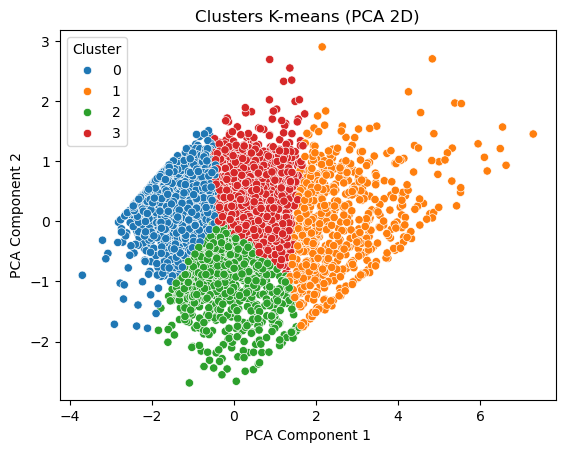

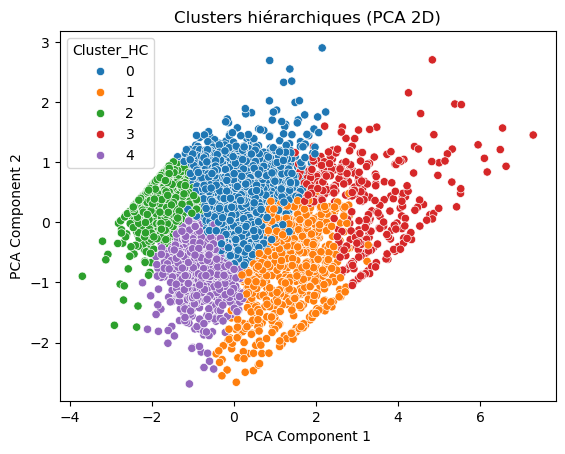

In [21]:
# Graphique 1 : clusters K-means dans l'espace 2D de la PCA
sns.scatterplot(x=rfm["PCA1"], y=rfm["PCA2"], hue=rfm["Cluster"], palette="tab10")
plt.title("Clusters K-means (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Graphique 2 : clusters hiérarchiques dans le même espace 2D
sns.scatterplot(x=rfm["PCA1"], y=rfm["PCA2"], hue=rfm["Cluster_HC"], palette="tab10")
plt.title("Clusters hiérarchiques (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

Séparation des clusters :

Dans les deux méthodes, les clusters apparaissent bien séparés dans l'espace 2D : chaque cluster occupe sa propre zone, avec très peu de chevauchement entre les couleurs.

- K-means : les 4 clusters forment des zones nettes. Les clients inactifs (cluster 0) sont à gauche, les nouveaux clients (cluster 2) en bas au centre, les clients occasionnels (cluster 3) en haut au centre, et les meilleurs clients (cluster 1) à droite. Ce dernier groupe est le plus étalé, car il réunit des clients aux valeurs très variées.

- Clustering hiérarchique : les 5 clusters sont aussi bien séparés, avec des frontières un peu moins régulières. L'élite (cluster 3) se détache à l'extrême droite, et les bons clients actifs (cluster 1) se placent juste à côté.

Il faut toutefois noter que les données forment un seul nuage continu, sans espace vide entre les groupes. Les clusters découpent ce nuage en zones plutôt qu'ils ne révèlent des groupes naturellement isolés : un client situé à la frontière entre deux clusters a un profil intermédiaire.

Comparaison avec les résultats avant réduction :

La PCA confirme les observations faites sur les graphiques Récence vs Fréquence vs Montant : on retrouve les mêmes segments, positionnés de façon cohérente. Avec 94 % de variance expliquée, cette représentation en 2D est fiable et valide la cohérence des deux segmentations. Le clustering hiérarchique y apparaît comme un affinement de K-means, surtout du côté des meilleurs clients.

# Définition des personas marketing

In [22]:
# Correspondance entre le numéro de cluster et le nom du segment
noms_segments = {1: "Champions", 3: "Occasionnels", 2: "Nouveaux clients", 0: "Inactifs"}

# Ajout du nom du segment pour chaque client
rfm["Segment"] = rfm["Cluster"].map(noms_segments)

# Tableau récapitulatif : médianes RFM par numéro de cluster
personas = rfm.groupby("Cluster")[["Recence", "Frequence", "Montant"]].median().round(1)

# Ajout du nom du segment correspondant à chaque numéro de cluster
personas["Segment"] = personas.index.map(noms_segments)

# Ajout du nombre de clients par cluster
personas["Effectif"] = rfm["Cluster"].value_counts()

# Ajout de la part de chaque cluster dans la clientèle (en %)
personas["Part (%)"] = (rfm["Cluster"].value_counts(normalize=True) * 100).round(1)

# Réorganisation des colonnes pour afficher le nom du segment en premier
personas = personas[["Segment", "Recence", "Frequence", "Montant", "Effectif", "Part (%)"]]

# Affichage
personas

,Segment,Recence,Frequence,Montant,Effectif,Part (%)
Cluster,,,,,,
0,Inactifs,184.0,1.0,304.2,1583,36.5
1,Champions,8.0,10.0,3719.1,701,16.2
2,Nouveaux clients,19.0,2.0,418.5,872,20.1
3,Occasionnels,51.0,4.0,1374.3,1182,27.2


In [23]:
# Export du dataset RFM avec les clusters et les segments, pour Data Studio et Streamlit
rfm.to_csv("rfm_segments.csv")

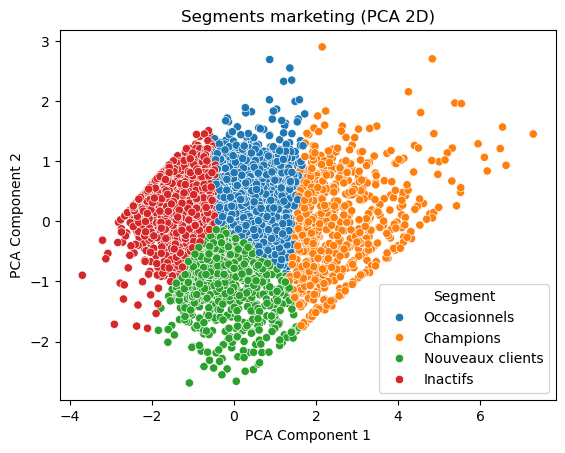

In [24]:
# Nuage de points des clients dans l'espace 2D de la PCA, coloré par segment marketing
sns.scatterplot(x=rfm["PCA1"], y=rfm["PCA2"], hue=rfm["Segment"], palette="tab10")
plt.title("Segments marketing (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

In [25]:
# Contribution de chaque variable RFM aux 2 composantes principales
composantes = pd.DataFrame(pca.components_, columns=X_scaled.columns, index=["PCA1", "PCA2"]).round(2)

# Affichage
composantes

,Recence,Frequence,Montant
PCA1,-0.51,0.62,0.60
PCA2,0.85,0.26,0.46


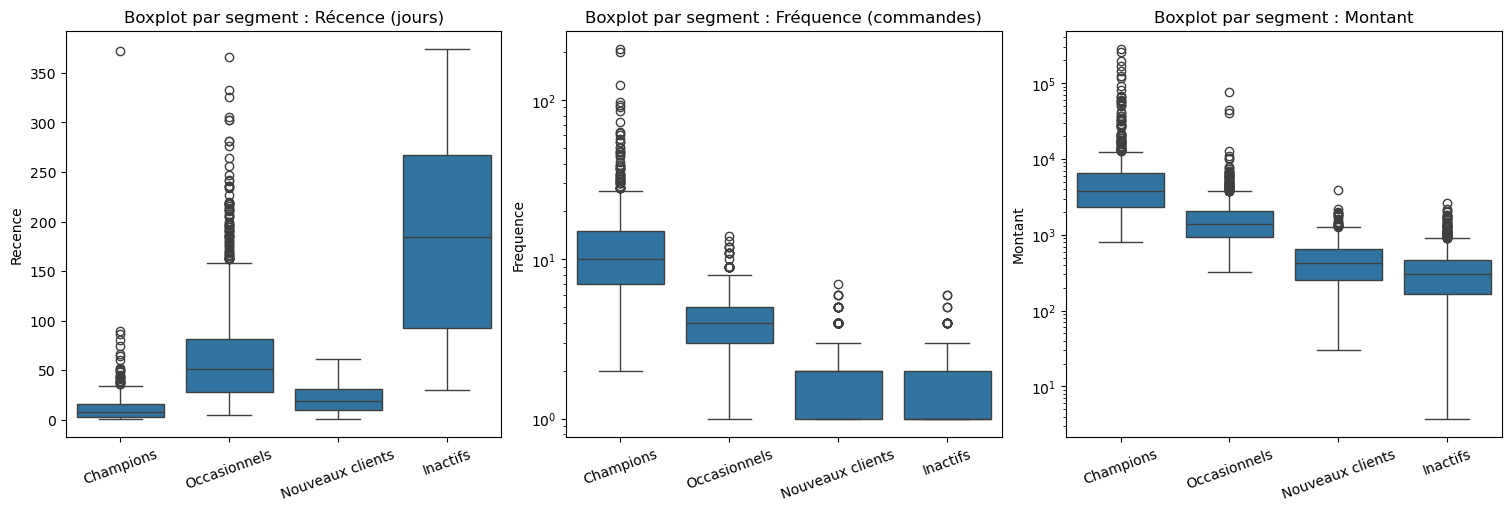

In [26]:
# Boxplots des 3 métriques RFM par segment (grille 1 x 3)
colonnes = ["Recence", "Frequence", "Montant"]
titres = ["Récence (jours)", "Fréquence (commandes)", "Montant"]

# Ordre d'affichage des segments, du plus rentable au moins actif
ordre_segments = ["Champions", "Occasionnels", "Nouveaux clients", "Inactifs"]

# Création de la figure avec 3 graphiques côte à côte
fig, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

# Un boxplot par métrique, avec un boxplot par segment
for col, titre, ax in zip(colonnes, titres, axs.flat):
    sns.boxplot(x=rfm["Segment"], y=rfm[col], order=ordre_segments, ax=ax)
    ax.set_title(f"Boxplot par segment : {titre}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

# Échelle logarithmique pour la fréquence et le montant, pour rendre les boxplots lisibles
axs[1].set_yscale("log")
axs[2].set_yscale("log")

# Affichage
plt.show()

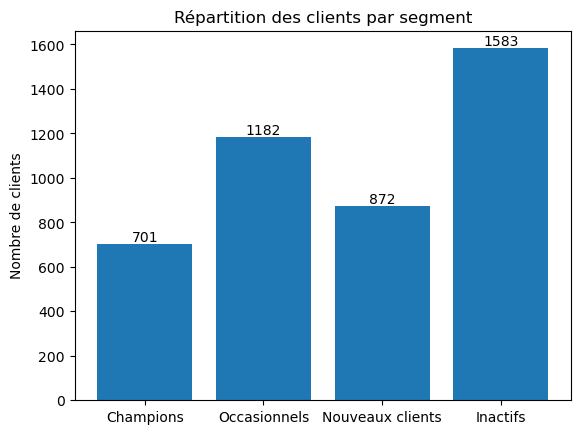

In [27]:
# Ordre d'affichage des segments, du plus rentable au moins actif
ordre_segments = ["Champions", "Occasionnels", "Nouveaux clients", "Inactifs"]

# Nombre de clients dans chaque segment, dans l'ordre choisi
repartition = rfm["Segment"].value_counts().reindex(ordre_segments)

# Graphique en barres de la répartition des clients par segment
plt.bar(repartition.index, repartition.values)

# Affichage du nombre de clients au-dessus de chaque barre
for i, valeur in enumerate(repartition.values):
    plt.text(i, valeur, str(valeur), ha="center", va="bottom")

# Titre et nom de l'axe vertical
plt.title("Répartition des clients par segment")
plt.ylabel("Nombre de clients")

# Affichage
plt.show()

# Conclusion : choix du modèle retenu

Les deux méthodes produisent des segmentations cohérentes, confirmées par la visualisation PCA (94 % de variance expliquée). Nous retenons K-means avec 4 clusters pour la segmentation finale, pour trois raisons :

- Lisibilité : 4 segments sont plus simples à présenter et à exploiter par les équipes marketing que 5.
- Équilibre : les clusters K-means sont plus équilibrés (de 701 à 1 583 clients) que les clusters hiérarchiques (de 343 à 1 517 clients).
- Correspondance avec les profils RFM classiques : les 4 clusters correspondent directement à des personas marketing clairs : Champions, Occasionnels, Nouveaux clients et Inactifs.

Le clustering hiérarchique reste un complément utile : il a permis d'identifier, parmi les meilleurs clients, une élite de 343 clients particulièrement rentables. Cette information pourra servir à cibler en priorité les actions les plus coûteuses (offres VIP, services premium).